bot commits removed: 17
Type
Issue               2210
Pull Request        1092
Extractor Commit     366
Core Commit          158
Release               17
Name: count, dtype: int64
Type     Core Commit  Extractor Commit  Issue  Pull Request  Release
Month                                                               
2025-09           19                30    210            79        3
2025-10            5                29    258            72        2
2025-11           16                52    231           116        1
2025-12           13                41    157            86        1
2026-01           13                44    230            97        1
2026-02            5                39    205            99        3
2026-03            8                16    188           105        3
2026-04            9                 8    131            66        0
2026-05           11                 2    158            84        0
2026-06           28                49    131           118  

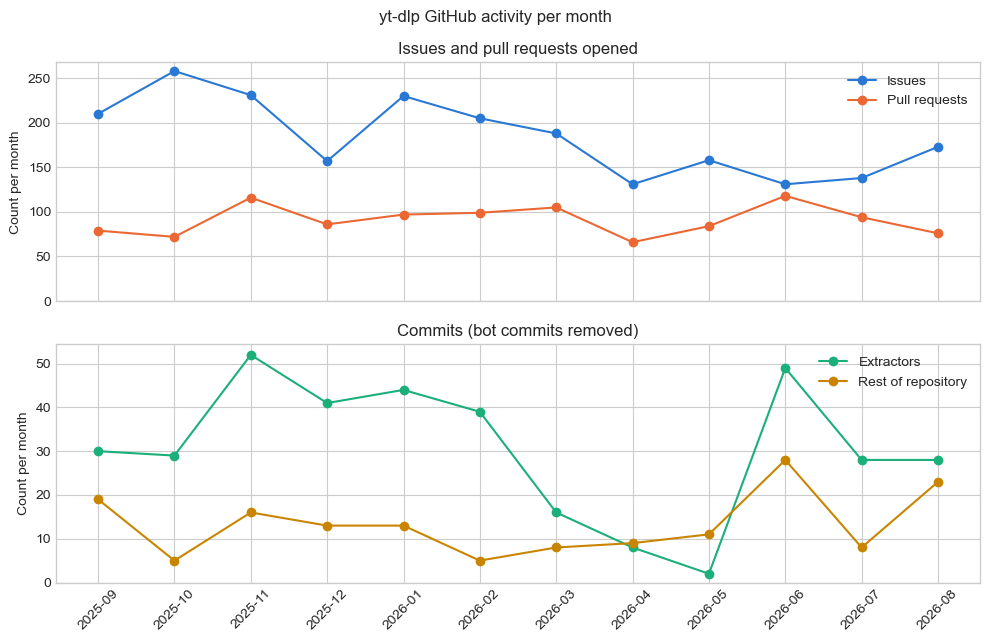

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# load the csv from the C# script
df = pd.read_csv('yt_dlp_architecture_data.csv')
df['Date'] = pd.to_datetime(df['Date'])

# remove commits made by bots (release commits by github-actions[bot])
bots = df['Type'].str.contains('Commit') & df['Author'].str.contains('[bot]', regex=False)
print("bot commits removed:", bots.sum())
df = df[~bots]

# drop the current month because it is not finished yet
df['Month'] = df['Date'].dt.to_period('M')
df = df[df['Month'] < pd.Timestamp.now().to_period('M')]

# totals for the table
print(df['Type'].value_counts())

# count activities per month
monthly = df.groupby(['Month', 'Type']).size().unstack(fill_value=0)
print(monthly)
months = monthly.index.astype(str)

# two plots, otherwise the issues make the commit lines too flat
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6.5), sharex=True)

ax1.plot(months, monthly['Issue'], marker='o', label='Issues', color='#2a78d6')
ax1.plot(months, monthly['Pull Request'], marker='o', label='Pull requests', color='#eb6834')
ax1.set_title('Issues and pull requests opened')
ax1.set_ylabel('Count per month')
ax1.set_ylim(bottom=0)
ax1.legend()

ax2.plot(months, monthly['Extractor Commit'], marker='o', label='Extractors', color='#1baf7a')
ax2.plot(months, monthly['Core Commit'], marker='o', label='Rest of repository', color='#c98500')
ax2.set_title('Commits (bot commits removed)')
ax2.set_ylabel('Count per month')
ax2.set_ylim(bottom=0)
ax2.legend()

plt.xticks(rotation=45)
plt.suptitle('yt-dlp GitHub activity per month')
plt.tight_layout()
plt.savefig('yt_dlp_activities.png', dpi=300)
plt.show()